In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 4")

### Section 1 : Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [7]:
os.makedirs('models',      exist_ok=True)
os.makedirs('predictions', exist_ok=True)
os.makedirs('plots',       exist_ok=True)

In [8]:
C = dict(blue='#1D4ED8', green='#15803D', red='#B91C1C', amber='#B45309', violet='#6D28D9')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


### Section 2 :Load Preprocessed Data

In [9]:
df = pd.read_csv('data/processed_traffic.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [10]:
NUM_COLS = ['Page_Loads', 'Unique_Visits', 'First_Time_Visits', 'Returning_Visits']
TARGET   = 'Page_Loads'
print(f'Loaded: {df.shape}  |  {df["Date"].min().date()} to {df["Date"].max().date()}')

Loaded: (2167, 6)  |  2014-09-14 to 2020-08-19


In [11]:
df.head()

,Date,Page_Loads,Unique_Visits,First_Time_Visits,Returning_Visits,DayName
0,2014-09-14,2146.0,1582.0,1430.0,152.0,Sunday
1,2014-09-15,3621.0,2528.0,2297.0,231.0,Monday
2,2014-09-16,3698.0,2630.0,2352.0,278.0,Tuesday
3,2014-09-17,3667.0,2614.0,2327.0,287.0,Wednesday
4,2014-09-18,3316.0,2366.0,2130.0,236.0,Thursday


### Section 3 : Feature Engineering

In [12]:
df_feat = df.copy()

In [13]:
# Calendar Features
df_feat['day_of_week']  = df_feat['Date'].dt.dayofweek
df_feat['day_of_month'] = df_feat['Date'].dt.day
df_feat['month']        = df_feat['Date'].dt.month
df_feat['week_of_year'] = df_feat['Date'].dt.isocalendar().week.astype(int)
df_feat['quarter']      = df_feat['Date'].dt.quarter
df_feat['year']         = df_feat['Date'].dt.year
df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)
df_feat['is_month_end'] = df_feat['Date'].dt.is_month_end.astype(int)
df_feat['is_month_start'] = df_feat['Date'].dt.is_month_start.astype(int)

In [14]:
# Fourier terms (capture weekly & yearly cycles)
for k in [1, 2]:
    df_feat[f'sin_week_{k}'] = np.sin(2 * np.pi * k * df_feat['day_of_week'] / 7)
    df_feat[f'cos_week_{k}'] = np.cos(2 * np.pi * k * df_feat['day_of_week'] / 7)

In [15]:
# Lag Features (Page_Loads)
for lag in [1, 2, 3, 7, 14, 21, 28]:
    df_feat[f'lag_{lag}'] = df_feat[TARGET].shift(lag)

In [16]:
# Rolling Statistics
for window in [7, 14, 30]:
    shifted = df_feat[TARGET].shift(1)
    df_feat[f'roll_mean_{window}'] = shifted.rolling(window).mean()
    df_feat[f'roll_std_{window}']  = shifted.rolling(window).std()
    df_feat[f'roll_max_{window}']  = shifted.rolling(window).max()
    df_feat[f'roll_min_{window}']  = shifted.rolling(window).min()

In [17]:
# Expanding mean (global trend signal)
df_feat['exp_mean'] = df_feat[TARGET].shift(1).expanding().mean()

# Visitor Ratio Features
df_feat['return_ratio'] = df_feat['Returning_Visits']   / (df_feat['Unique_Visits'] + 1)
df_feat['new_ratio']    = df_feat['First_Time_Visits']  / (df_feat['Unique_Visits'] + 1)
df_feat['loads_per_visit'] = df_feat[TARGET] / (df_feat['Unique_Visits'] + 1)

In [18]:
# Lag features for other traffic metrics
for col in ['Unique_Visits', 'Returning_Visits']:
    df_feat[f'{col}_lag1'] = df_feat[col].shift(1)
    df_feat[f'{col}_lag7'] = df_feat[col].shift(7)

In [19]:
# Drop NaN rows created by lagging
df_feat = df_feat.dropna().reset_index(drop=True)
print(f'Feature-engineered shape: {df_feat.shape}')

Feature-engineered shape: (2137, 46)


In [20]:
FEAT_COLS = [c for c in df_feat.columns
             if c not in ['Date', 'DayName', TARGET] + NUM_COLS]
print(f'Total features: {len(FEAT_COLS)}')
print(FEAT_COLS)

Total features: 40
['day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'is_weekend', 'is_month_end', 'is_month_start', 'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_max_7', 'roll_min_7', 'roll_mean_14', 'roll_std_14', 'roll_max_14', 'roll_min_14', 'roll_mean_30', 'roll_std_30', 'roll_max_30', 'roll_min_30', 'exp_mean', 'return_ratio', 'new_ratio', 'loads_per_visit', 'Unique_Visits_lag1', 'Unique_Visits_lag7', 'Returning_Visits_lag1', 'Returning_Visits_lag7']


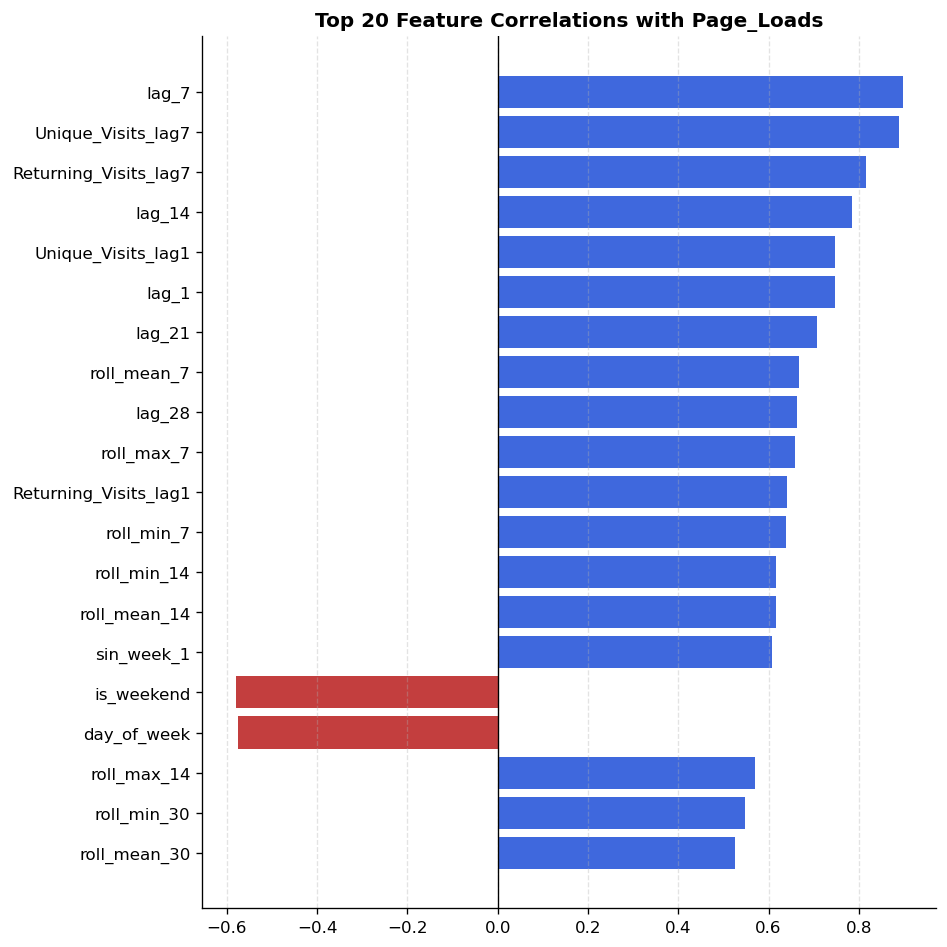

In [21]:
# Feature importance preview (correlation with target)
corr_target = df_feat[FEAT_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
top20 = corr_target.head(20)
colors_bar = [C['blue'] if v > 0 else C['red'] for v in top20]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 20 Feature Correlations with Page_Loads', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/09_feature_correlations.png', bbox_inches='tight')
plt.show()

### Section 4 : Train/Test

In [22]:
split_idx = int(len(df_feat) * 0.80)
train_df  = df_feat.iloc[:split_idx].copy()
test_df   = df_feat.iloc[split_idx:].copy()

In [23]:
X_train, y_train = train_df[FEAT_COLS], train_df[TARGET]
X_test,  y_test  = test_df[FEAT_COLS],  test_df[TARGET]

print(f'Train: {train_df["Date"].min().date()} to {train_df["Date"].max().date()}  ({len(train_df):,} rows)')
print(f'Test : {test_df["Date"].min().date()} to {test_df["Date"].max().date()}   ({len(test_df):,} rows)')

Train: 2014-10-14 to 2019-06-18  (1,709 rows)
Test : 2019-06-19 to 2020-08-19   (428 rows)


In [24]:
# Save split dates
split_info = {'train_end': str(train_df['Date'].max().date()),
              'test_start': str(test_df['Date'].min().date())}
pd.Series(split_info).to_json('data/split_info.json')

In [25]:
def save_pred(name, dates, y_true, y_pred):
    """Save predictions CSV for NB3"""
    pd.DataFrame({'Date': dates, 'y_true': y_true, 'y_pred': y_pred}).to_csv(
        f'predictions/{name}.csv', index=False)
    print(f'  Saved predictions/{name}.csv')

In [26]:
def rmse(a, b): return np.sqrt(mean_squared_error(a, b))
def mape(a, b): return mean_absolute_percentage_error(a, b) * 100

### Section 5 : Model Training

#### 5.1 Sarima 

In [27]:
print('Training SARIMA(1,1,1)(1,1,1,7) ...')
ts_train = train_df.set_index('Date')[TARGET]
ts_test  = test_df.set_index('Date')[TARGET]

Training SARIMA(1,1,1)(1,1,1,7) ...


In [28]:
sarima = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                        Page_Loads   No. Observations:                 1709
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -12222.431
Date:                           Sat, 04 Apr 2026   AIC                          24454.861
Time:                                   15:26:12   BIC                          24482.030
Sample:                               10-14-2014   HQIC                         24464.922
                                    - 06-18-2019                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7893      0.022     35.851      0.000       0.746       0.832
ma.L1         -0.9343      0.014    -67.819

In [29]:
sarima_pred = np.maximum(sarima_fit.forecast(steps=len(ts_test)).values, 0)
print(f'SARIMA  RMSE={rmse(ts_test.values, sarima_pred):,.1f}  MAPE={mape(ts_test.values, sarima_pred):.2f}%')

SARIMA  RMSE=1,119.4  MAPE=22.22%


In [30]:
sarima_fit.save('models/sarima_model.pkl')
save_pred('sarima', ts_test.index, ts_test.values, sarima_pred)

  Saved predictions/sarima.csv


#### 5.2 Prophet

In [31]:
print('Training Prophet ...')
prop_train = train_df[['Date', TARGET]].rename(columns={'Date':'ds', TARGET:'y'})
prop_test  = test_df[['Date', TARGET]].rename(columns={'Date':'ds', TARGET:'y'})

Training Prophet ...


In [32]:
prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                  daily_seasonality=False, seasonality_mode='multiplicative',
                  changepoint_prior_scale=0.05, seasonality_prior_scale=10)
prophet.fit(prop_train)

15:29:42 - cmdstanpy - INFO - Chain [1] start processing
15:29:43 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
future  = prophet.make_future_dataframe(periods=len(prop_test))
fc_prop = prophet.predict(future)
prop_pred = np.maximum(
    fc_prop[fc_prop['ds'].isin(prop_test['ds'])]['yhat'].values, 0)

print(f'Prophet RMSE={rmse(prop_test["y"].values, prop_pred):,.1f}  MAPE={mape(prop_test["y"].values, prop_pred):.2f}%')


Prophet RMSE=612.3  MAPE=13.40%


In [34]:
joblib.dump(prophet, 'models/prophet_model.pkl')
save_pred('prophet', prop_test['ds'].values, prop_test['y'].values, prop_pred)

  Saved predictions/prophet.csv


#### 5.3 Random Forwst

In [36]:
print('Tuning Random Forest ...')
tscv = TimeSeriesSplit(n_splits=5)

Tuning Random Forest ...


In [37]:
rf_params = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5]
}

In [38]:
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42), rf_params,
    n_iter=25, scoring='neg_root_mean_squared_error',
    cv=tscv, random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
print('Best RF params:', rf_search.best_params_)

Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [39]:
rf_pred = rf_best.predict(X_test)
print(f'RF      RMSE={rmse(y_test.values, rf_pred):,.1f}  MAPE={mape(y_test.values, rf_pred):.2f}%')
joblib.dump(rf_best, 'models/rf_model.pkl')
save_pred('rf', test_df['Date'].values, y_test.values, rf_pred)

RF      RMSE=380.4  MAPE=7.59%
  Saved predictions/rf.csv


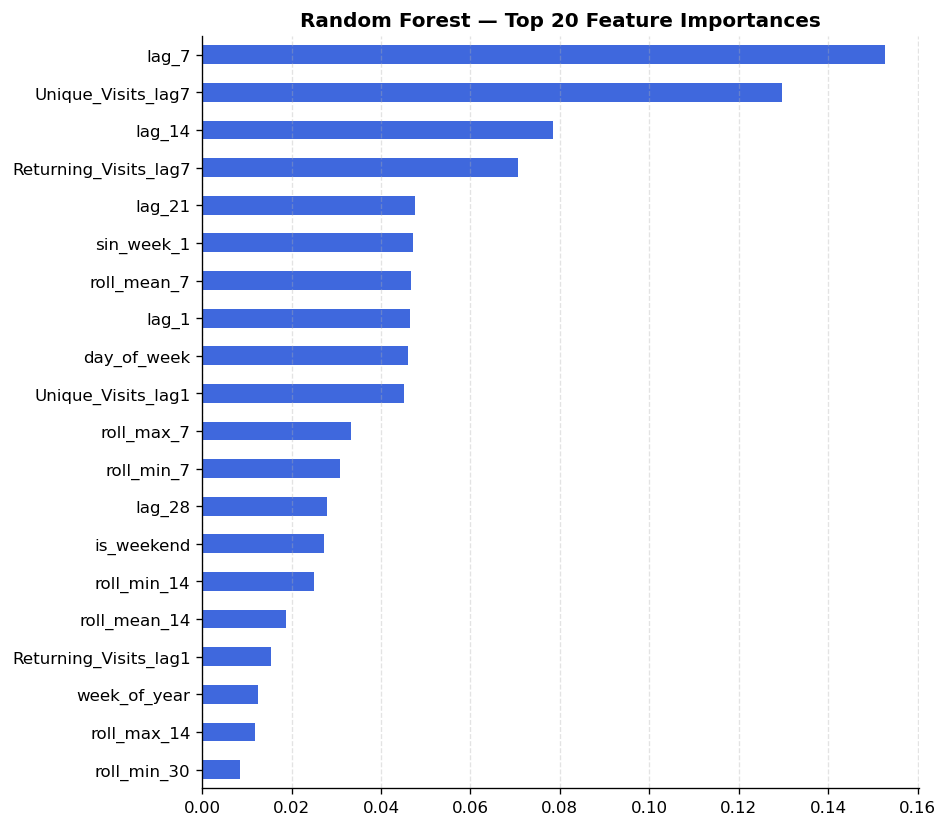

In [40]:
# Feature importance
fi = pd.Series(rf_best.feature_importances_, index=FEAT_COLS).sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(8, 7))
fi.plot.barh(ax=ax, color=C['blue'], alpha=0.85)
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/10_rf_importance.png', bbox_inches='tight')
plt.show()

#### 5.4 XGBoost